In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [ ]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep2.h5ad')
experiment_name = 'bd-rhap-rep2-X'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/{experiment_name}"
# This is where the GRN files are stored.
output_dir_grn = Path(op.join(output_dir, "grn"))
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)


In [ ]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"

In [ ]:
os.makedirs(analysis_output_dir, exist_ok=True)

In [ ]:
adata_raw.obs['celltype_semi_manual'].value_counts()

celltype_semi_manual
cd14+_monocytes    6942
cd14-_monocytes    1341
cd4+_tcells         964
nk_cells            613
cd8+_tcells         348
DC                  347
pDC                 205
b_cells             165
Name: count, dtype: int64

In [6]:
grn_adata = retrieve_top_edges(grn_adata, output_dir_grn, percentage=0.1 )

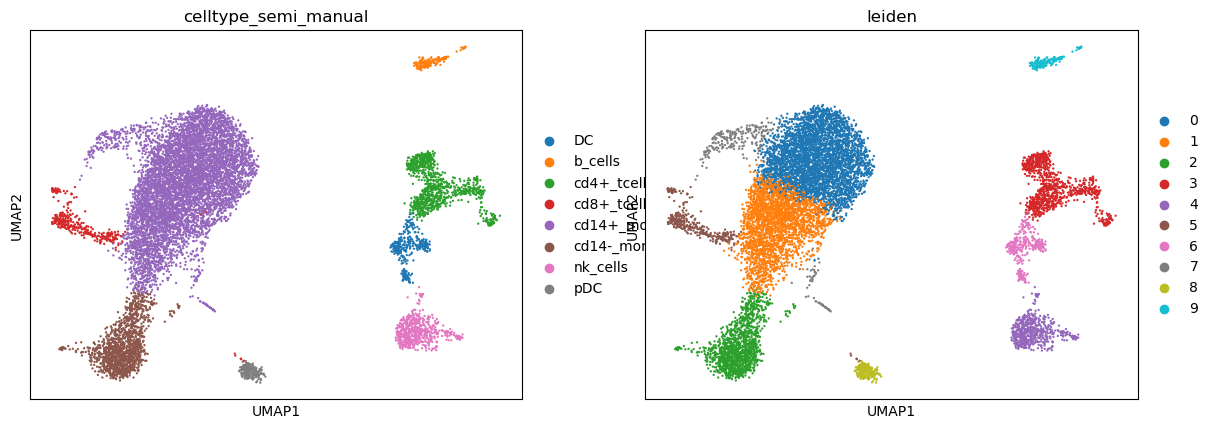

In [7]:
with plt.rc_context(): 
    sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'gex_clustering_annotation_umap.pdf'), bbox_inches="tight")



In [8]:
grn_adata.var = grn_adata.var.set_index('index')



In [9]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [10]:
sc.tl.tsne(grn_adata)

In [11]:
sc.tl.leiden(grn_adata, resolution=0.18)

In [12]:
with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'celltype_semi_manual'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

In [13]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata, 'celltype_semi_manual', col_grn)
    print(f"{col_grn} score: {score}")
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
leiden score: 0.9499313501144164


In [14]:
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


In [15]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [16]:
grn_adata2.obs = grn_adata.obs

In [ ]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


In [ ]:
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata2, output_dir_grn, index_list)

In [25]:
grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']

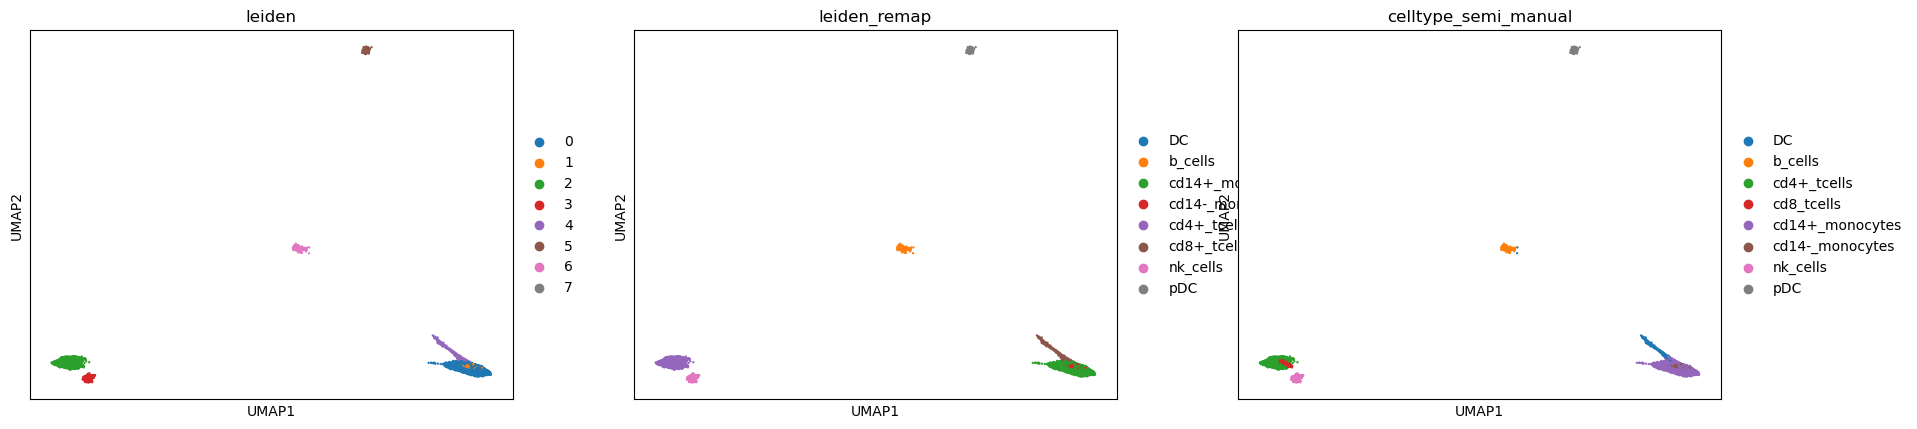

In [26]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

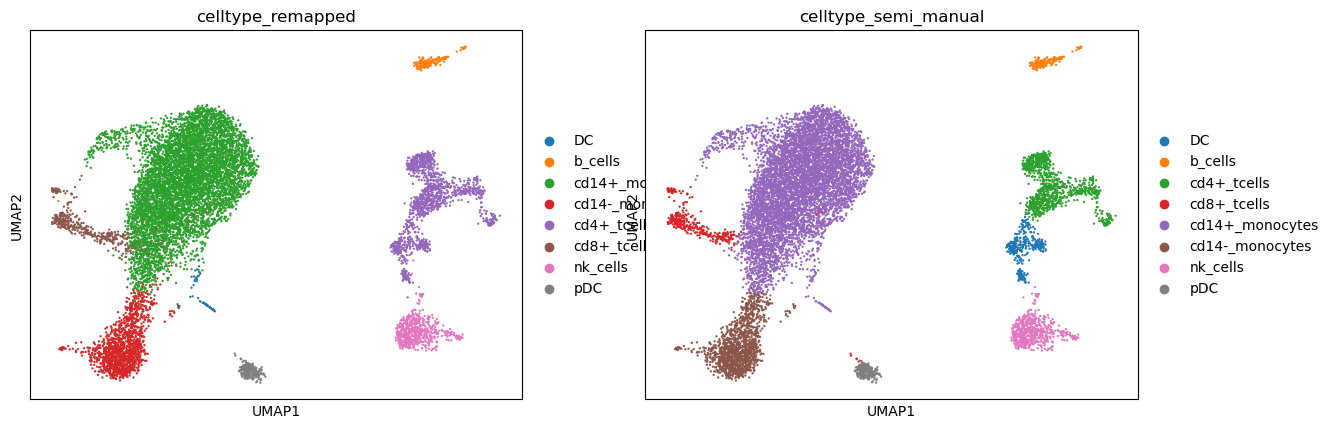

In [27]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual' ])

In [28]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [ ]:
grn_adata3 = add_external_grn(grn_ad=grn_adata3,external_grn=collectri,name_grn='collectri')

In [ ]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'celltype_semi_manual'
top_per_source = 30
min_reg_size = 3
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 10925 × 264942
    obs: 'Unnamed: 0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'cd14+_monocytes_nonzero', 'cd14+_monocytes_candidate_edge', 'cd14-_monocytes_nonzero', 'cd14-_monocytes_candidate_edge', 'cd4+_tcells_nonzero', 'cd4+_tcells_candidate_edge', 'nk_cells_nonzero', 'nk_cells_candidate_edge', 'cd8+_tcells_nonzero', 'cd8+_tcells_candidate_e

In [32]:
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)


Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC


In [ ]:
all_regulons = make_cluster_regulon_dataframe(keep_edges)
all_regulons.to_csv(op.join(analysis_output_dir, 'regulons.tsv'), sep = '\t')

In [ ]:
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')

DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8_tcells
nk_cells
pDC


In [ ]:
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)


In [ ]:
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

In [ ]:
# grn_adata3.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
# all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

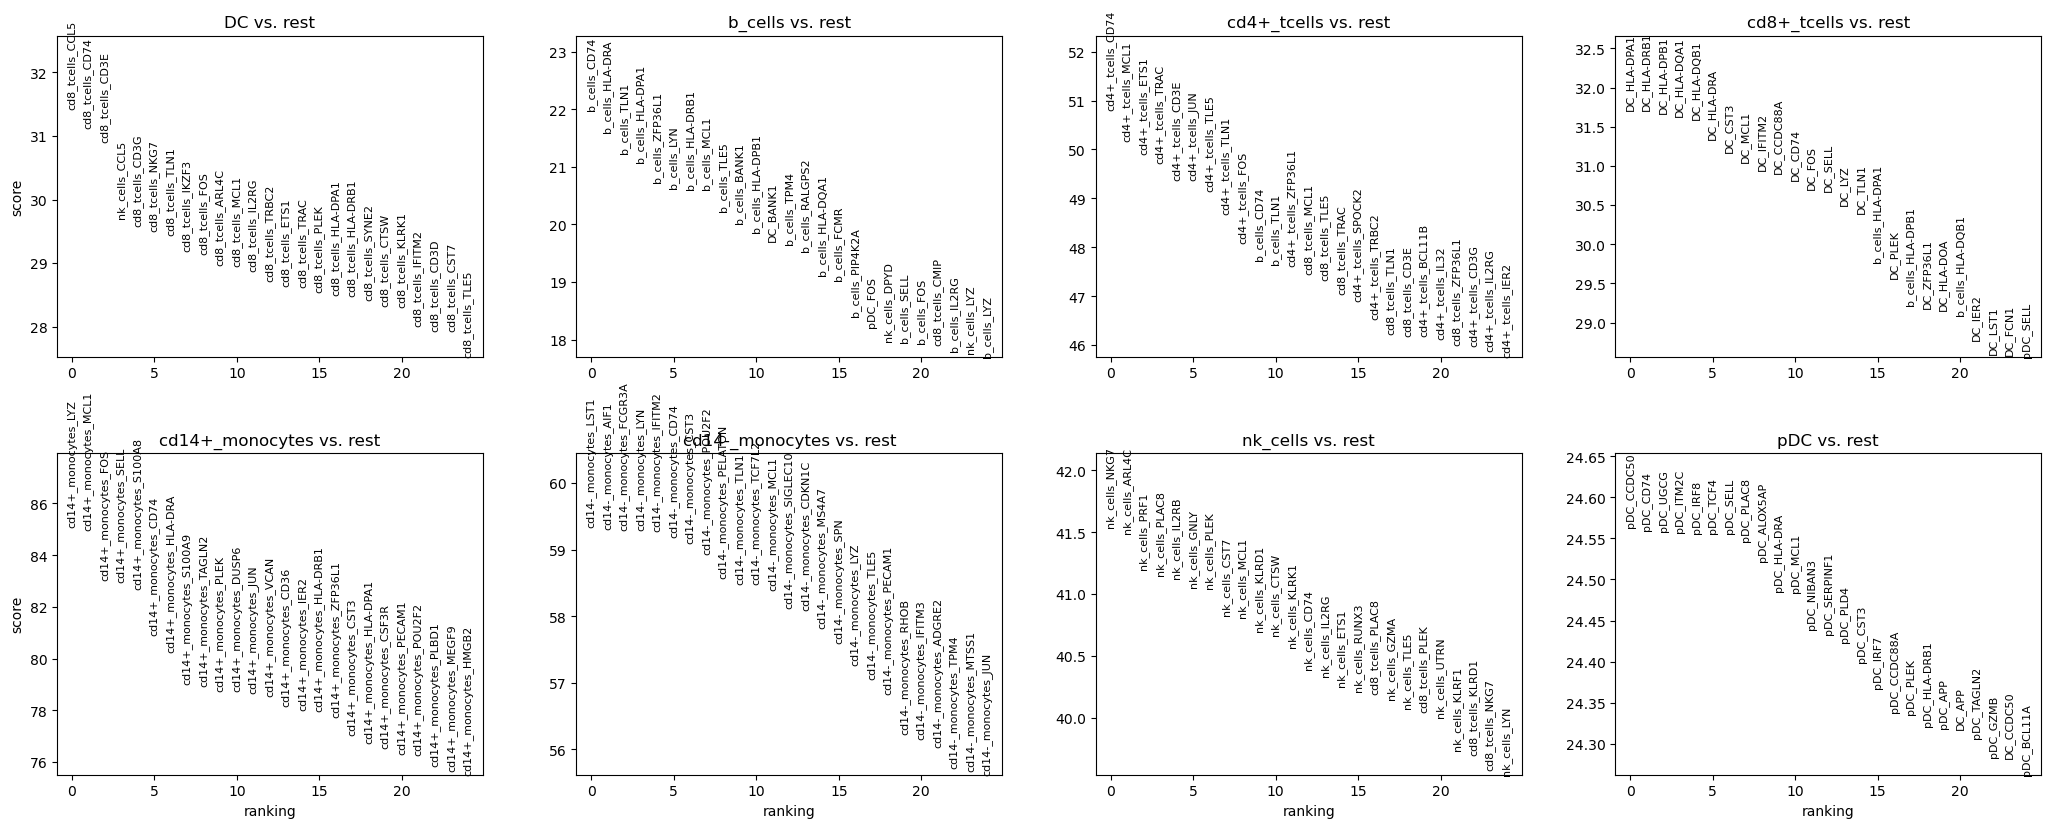

In [ ]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [ ]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column, n_genes=10)

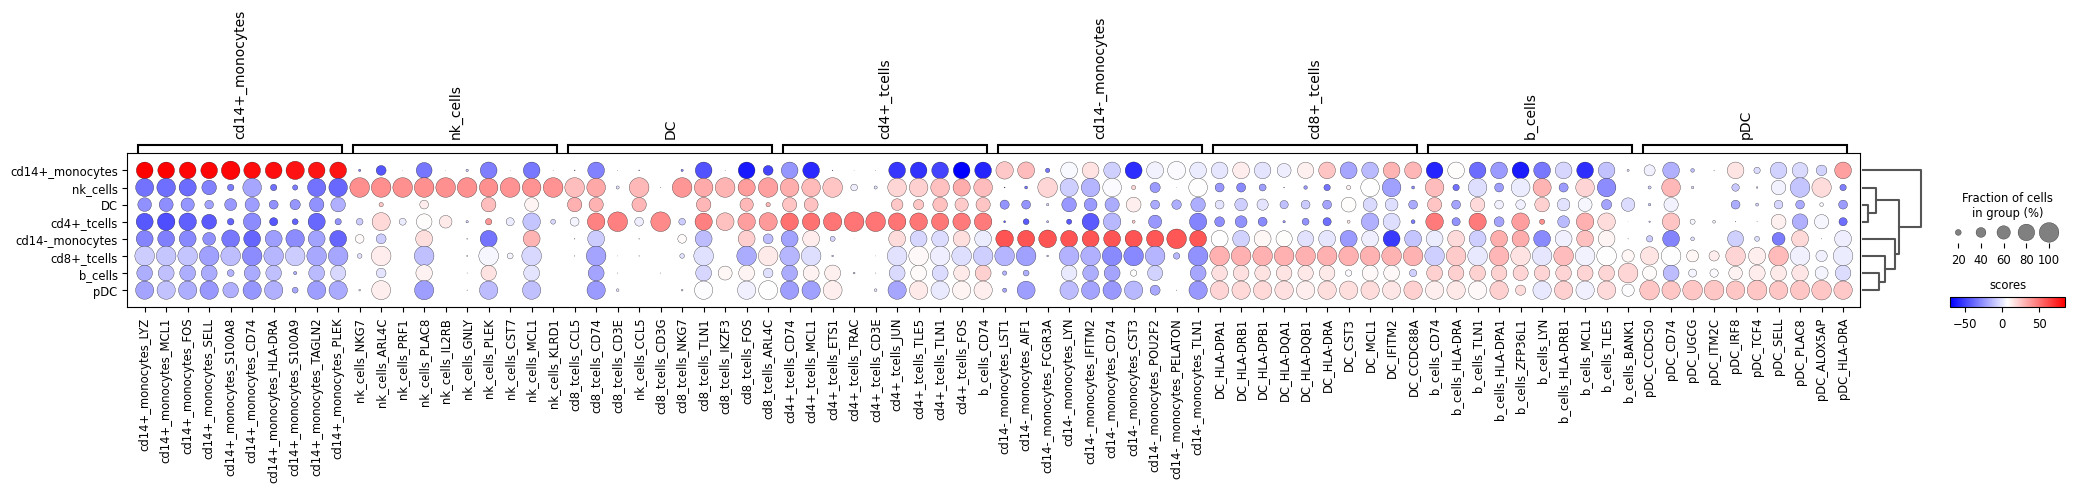

In [ ]:
pp.show()

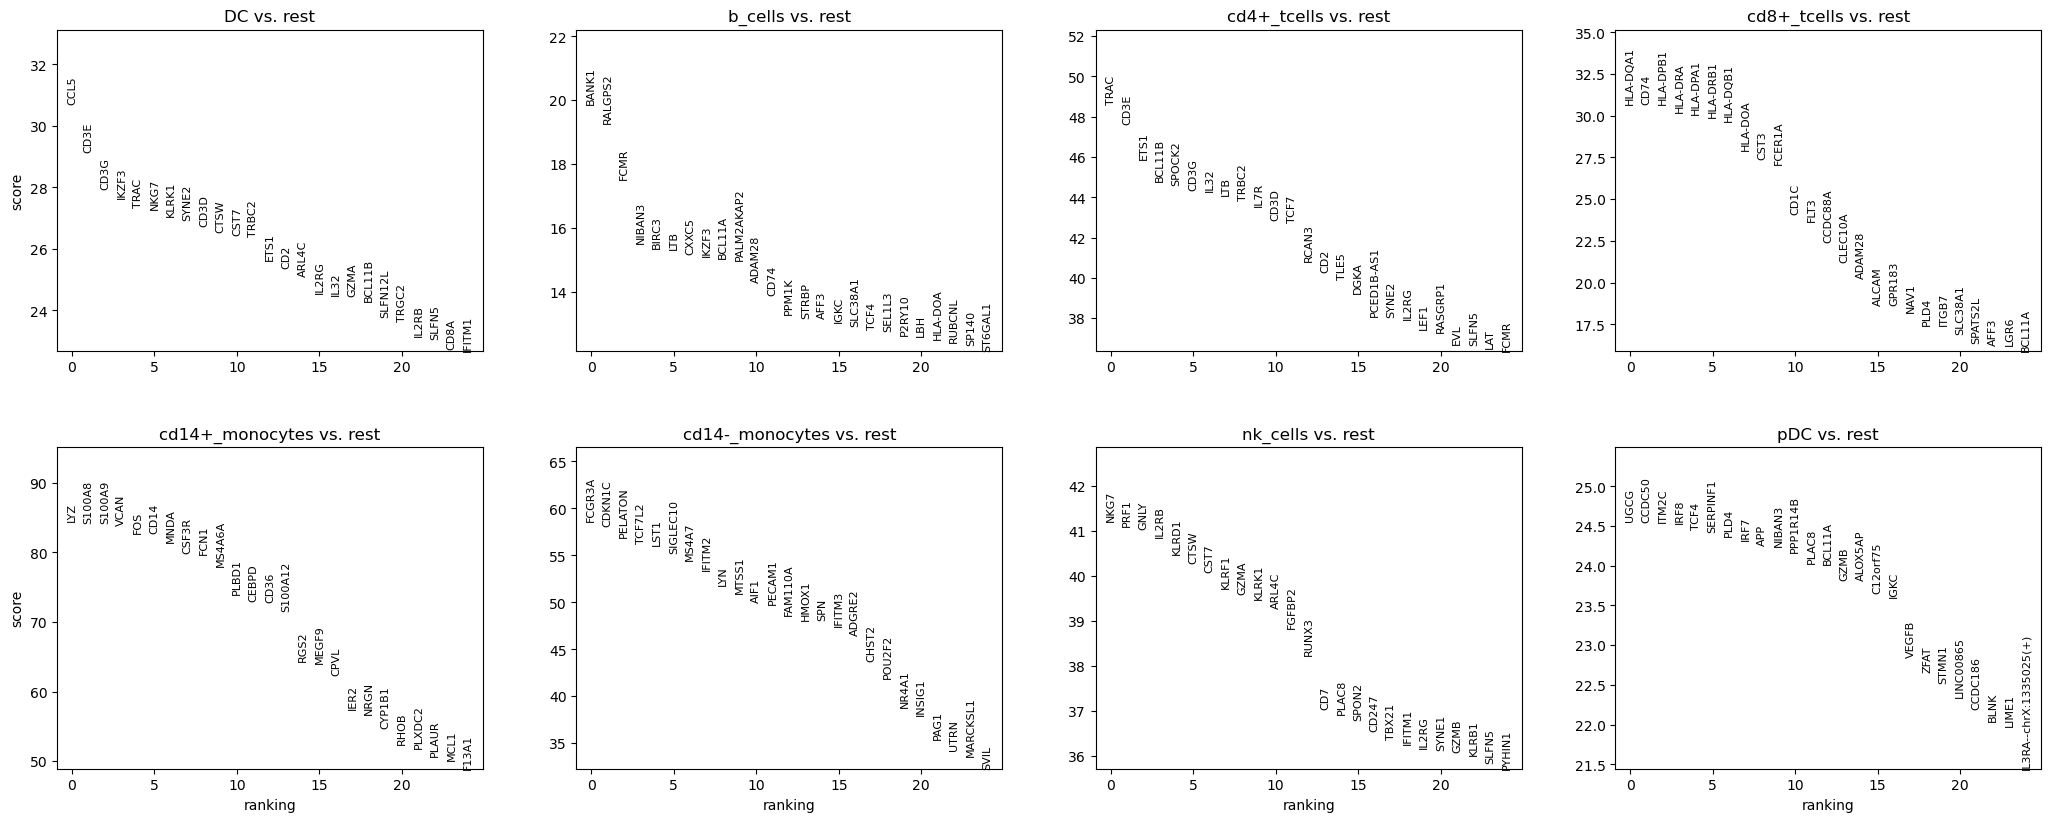

In [ ]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(adata_raw, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(adata_raw, n_genes=25, sharey=False, key="wilcoxon")

In [ ]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')

In [ ]:
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))

NameError: name 'bcrank_entropy' is not defined